In [1]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov
from godmax import gaussian_tension






/tmp/ipykernel_902286/854669679.py:10: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


In [2]:
# ldir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/'
# # df = pk.load(open(ldir + 'mcmc_v10_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_7000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))

# # df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v9_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4500_warmup_3500_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v10_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_7000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))

ldir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Feb/'
# df = pk.load(open(ldir + 'mcmc_v10_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_7000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))

# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v9_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4500_warmup_3500_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v10_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_7000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
df = pk.load(open(ldir + 'mcmc_v10_widemuej_nzfix_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))




In [3]:
samps = []
keys = []
for key in df:
    # if ('base' not in key) and ('decentered' not in key):
        # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging']:
        if key not in ['RUN_SETTINGS', 'diverging']:
            if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                for jb in range(4):
                    samps.append(df[key][:, jb])
                    keys.append(key + '_' + str(jb))
                    print(df[key][:, jb].shape)
            else:
                samps.append(df[key])
                keys.append(key)            

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')


ind_post = keys.index('potential_energy')
post = -1.* samps[:,ind_post]

map_ind = np.where(post == post.max())[0][0]

saved_bestfit = {}
for jk, key in enumerate(keys):
    print(key, samps[map_ind, jk])
    saved_bestfit[key] = samps[map_ind, jk]



(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
A_IA 0.14377885207895114
A_IA_base 0.14377885207895114
Delta_z_bias_array_0 0.007653930225780798
Delta_z_bias_array_1 -0.012598270941276137
Delta_z_bias_array_2 -0.012841804698650358
Delta_z_bias_array_3 0.013288081442525992
Delta_z_bias_array_decentered_0 0.42521834587671103
Delta_z_bias_array_decentered_1 -0.8398847294184092
Delta_z_bias_array_decentered_2 -1.1674367907863963
Delta_z_bias_array_decentered_3 0.7816518495603524
Ob0 0.04302213809734518
Ob0_base -1.0466792853982227
Om0 0.2541951448373219
Om0_base -0.6870728274401721
alpha_ky 1.049289760822429
alpha_ky_base 0.7393464123364355
alpha_nt 0.22447369527641473
alpha_nt_base -0.3063156566830232
eta_IA 1.002030465527282
eta_IA_base 1.002030465527282
h 0.7046634431189261
h_base 0.06995164678389365
mu_beta 0.2209875338571503
mu_beta_base -2.1160498645713988
mult_shear_bias_a

In [4]:
# potential_energy -4916.635080802822
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)


# saved_bestift
from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 4
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])


analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]

lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)


for key in saved_bestfit.keys():
    if key in list(sim_params_dict.keys()):
        sim_params_dict[key] = float(saved_bestfit[key])
    if key in list(sim_params_dict['cosmo'].keys()):
        sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
        if key == 'h':
            sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
    if key in list(other_params_dict.keys()):
        other_params_dict[key] = float(saved_bestfit[key])
for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
    other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
    other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']




In [5]:
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)



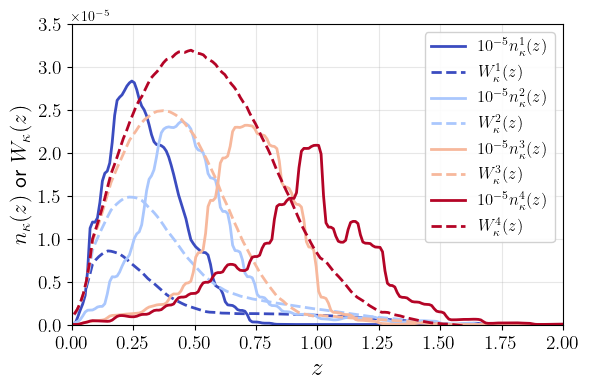

In [27]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Create a colormap from blue to red for jb values
colors = plt.cm.coolwarm(np.linspace(0, 1, 4))  # 4 colors from blue to red

plt.figure(figsize=(6, 4))  # Larger figure size

for jb in range(4):
    # Same color for both curves with the same jb value
    color = colors[jb]
    
    # Plot with better line styles and thicknesses
    plt.plot(Cls_test.z_array_nz, 1e-5*Cls_test.pzs_inp_mat[jb,:], 
             ls='-', lw=2, color=color, 
             label=f'$10^{{-5}} n^{{{jb+1}}}_{{\\kappa}}(z)$')
    
    plt.plot(Cls_test.z_array_for_Cls, Cls_test.Wk_mat[jb,:], 
             ls='--', lw=2, color=color, 
             label=f'$W^{{{jb+1}}}_{{\\kappa}}(z)$')

# Improve the plot appearance
plt.legend(frameon=True, framealpha=0.9, fontsize=12)
plt.xlabel(r'$z$', fontsize=18)
plt.ylabel(r'$n_{\kappa}(z)$ or $W_{\kappa}(z)$', fontsize=16)
plt.xlim(0.0, 2.0)
plt.ylim(0.0, 3.5e-5)
plt.grid(True, alpha=0.3)
#set the tick label sizes:
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
plt.savefig(save_plot_dir + 'Wk_nz.pdf', bbox_inches='tight')



(0.0, 2.0)

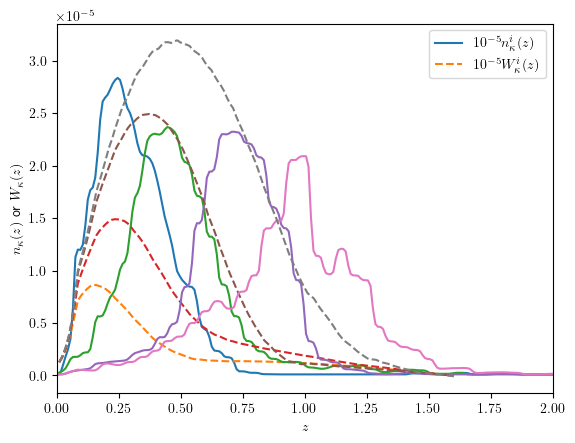

In [17]:
pl.figure()
for jb in range(4):
    if jb == 0:
        pl.plot(Cls_test.z_array_nz, 1e-5*Cls_test.pzs_inp_mat[jb,:], ls='-', label=r'$10^{-5} n^{i}_{\kappa}(z)$')
        pl.plot(Cls_test.z_array_for_Cls, Cls_test.Wk_mat[jb,:], ls='--', label=r'$W^{i}_{\kappa}(z)$')
    else:
        pl.plot(Cls_test.z_array_nz, 1e-5*Cls_test.pzs_inp_mat[jb,:], ls='-')
        pl.plot(Cls_test.z_array_for_Cls, Cls_test.Wk_mat[jb,:], ls='--')
pl.legend()
pl.xlabel(r'$z$')
pl.ylabel(r'$n_{\kappa}(z)$ or $W_{\kappa}(z)$')
pl.xlim(0.0, 2.0)

